# Initialisation Spark et librairies

In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("FruitsProject") \
    .getOrCreate()

Starting Spark application


ID,YARN Application ID,Kind,State,Spark UI,Driver log,User,Current session?
0,application_1749738634397_0001,pyspark,idle,Link,Link,None,✔


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

SparkSession available as 'spark'.


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [2]:
import pandas as pd
import numpy as np
import io
import os
import tensorflow as tf
from PIL import Image
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras import Model


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [3]:
from pyspark.sql.functions import col, pandas_udf, PandasUDFType, element_at, split

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

# Chemin S3 et import des images

In [4]:
PATH = 's3://projet-fruits-nasima'
PATH_Data = PATH + '/images/Test1'      
PATH_Result = PATH + '/Results'         
print('PATH:        ' + PATH + 
      '\nPATH_Data:   ' + PATH_Data + 
      '\nPATH_Result: ' + PATH_Result)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

PATH:        s3://projet-fruits-nasima
PATH_Data:   s3://projet-fruits-nasima/images/Test1
PATH_Result: s3://projet-fruits-nasima/Results

In [5]:
PATH_Data ="s3://projet-fruits-nassima/images/Test1"

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [6]:
print(PATH_Data)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

s3://projet-fruits-nassima/images/Test1

In [7]:

images = spark.read.format("binaryFile") \
  .option("pathGlobFilter", "*.jpg") \
  .option("recursiveFileLookup", "true") \
  .load(PATH_Data)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [8]:
images.show(5)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+--------------------+-------------------+------+--------------------+
|                path|   modificationTime|length|             content|
+--------------------+-------------------+------+--------------------+
|s3://projet-fruit...|2025-05-16 07:17:16|  5240|[FF D8 FF E0 00 1...|
|s3://projet-fruit...|2025-05-16 07:17:16|  5055|[FF D8 FF E0 00 1...|
|s3://projet-fruit...|2025-05-16 07:17:16|  4896|[FF D8 FF E0 00 1...|
|s3://projet-fruit...|2025-05-16 07:17:16|  4516|[FF D8 FF E0 00 1...|
|s3://projet-fruit...|2025-05-16 07:17:16|  4473|[FF D8 FF E0 00 1...|
+--------------------+-------------------+------+--------------------+
only showing top 5 rows

In [9]:
from pyspark.sql.functions import col, pandas_udf, PandasUDFType, element_at, split, udf

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

# Extraction des labels

In [10]:
images = images.withColumn('label', element_at(split(images['path'], '/'),-2))
print(images.printSchema())
print(images.select('path','label').show(5,False))

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

root
 |-- path: string (nullable = true)
 |-- modificationTime: timestamp (nullable = true)
 |-- length: long (nullable = true)
 |-- content: binary (nullable = true)
 |-- label: string (nullable = true)

None
+----------------------------------------------------------------+-----------+
|path                                                            |label      |
+----------------------------------------------------------------+-----------+
|s3://projet-fruits-nassima/images/Test1/Apple Red 1/3_100.jpg   |Apple Red 1|
|s3://projet-fruits-nassima/images/Test1/Apple Red 1/r_99_100.jpg|Apple Red 1|
|s3://projet-fruits-nassima/images/Test1/Apricot 1/r_34_100.jpg  |Apricot 1  |
|s3://projet-fruits-nassima/images/Test1/Avocado 1/r_78_100.jpg  |Avocado 1  |
|s3://projet-fruits-nassima/images/Test1/Apricot 1/3_100.jpg     |Apricot 1  |
+----------------------------------------------------------------+-----------+
only showing top 5 rows

None

# Modele MobilnetV2

In [11]:
import tensorflow as tf
from PIL import Image
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras import Model

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [12]:
model = MobileNetV2(weights='imagenet',
                    include_top=True,
                    input_shape=(224, 224, 3))

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

In [13]:
new_model = Model(inputs=model.input,
                  outputs=model.layers[-2].output)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [14]:
new_model.summary()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Model: "functional"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │

In [15]:
brodcast_weights = sc.broadcast(new_model.get_weights())

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

# Pretraitement et vectorisation

In [16]:
def model_fn():
    """
    Returns a MobileNetV2 model with top layer removed 
    and broadcasted pretrained weights.
    """
    model = MobileNetV2(weights='imagenet',
                        include_top=True,
                        input_shape=(224, 224, 3))
    for layer in model.layers:
        layer.trainable = False
    new_model = Model(inputs=model.input,
                  outputs=model.layers[-2].output)
    new_model.set_weights(brodcast_weights.value)
    return new_model

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [17]:
def preprocess(content):
    """
    Preprocesses raw image bytes for prediction.
    """
    img = Image.open(io.BytesIO(content)).resize([224, 224])
    arr = img_to_array(img)
    return preprocess_input(arr)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [18]:
def featurize_series(model, content_series):
    """
    Featurize a pd.Series of raw images using the input model.
    :return: a pd.Series of image features
    """
    input = np.stack(content_series.map(preprocess))
    preds = model.predict(input)
    # For some layers, output features will be multi-dimensional tensors.
    # We flatten the feature tensors to vectors for easier storage in Spark DataFrames.
    output = [p.flatten() for p in preds]
    return pd.Series(output)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [19]:
from pyspark.sql.pandas.functions import pandas_udf
from typing import Iterator, Tuple
import pandas as pd

@pandas_udf("array<float>")
def featurize_udf(content_series_iter: Iterator[pd.Series]) -> Iterator[pd.Series]:
    model = model_fn()
    for content_series in content_series_iter:
        yield featurize_series(model, content_series)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [20]:
features_df = images.sample(False, 1.0).repartition(20).select(col("path"),
                                                               col("label"),
                                                               featurize_udf("content").alias("features")
                                                              )

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [21]:
PATH_Result ="s3://projet-fruits-nassima/Results"

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [22]:
print(PATH_Result)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

s3://projet-fruits-nassima/Results

# Sauvegarde dans S3

In [23]:
features_df.write.mode("overwrite").parquet(PATH_Result)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [24]:
df = pd.read_parquet(PATH_Result, engine='pyarrow')

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [25]:
df.loc[0,'features'].shape

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

(1280,)

In [26]:
#df = df.sample(frac=0.5, random_state=42)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [27]:
df

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

                                                 path  ...                                           features
0   s3://projet-fruits-nassima/images/Test1/Aprico...  ...  [0.8995911, 0.0, 0.0, 0.0, 0.037708547, 0.0168...
1   s3://projet-fruits-nassima/images/Test1/Apple ...  ...  [0.40983528, 0.22716263, 0.14898795, 0.0, 0.13...
2   s3://projet-fruits-nassima/images/Test1/Avocad...  ...  [0.6423951, 0.03210058, 0.19703434, 0.05542104...
3   s3://projet-fruits-nassima/images/Test1/Apple ...  ...  [0.50753546, 0.2660061, 0.062371127, 0.0, 0.72...
4   s3://projet-fruits-nassima/images/Test1/Aprico...  ...  [0.7739645, 0.042797294, 0.0, 0.0, 0.0, 0.0520...
5   s3://projet-fruits-nassima/images/Test1/Avocad...  ...  [0.33077154, 0.0, 0.2054653, 0.0, 0.0, 0.16849...
6   s3://projet-fruits-nassima/images/Test1/Banana...  ...  [0.04958038, 0.20483069, 0.08560451, 0.0, 0.62...
7   s3://projet-fruits-nassima/images/Test1/Apple ...  ...  [0.12584046, 0.07077704, 0.0, 0.0, 0.30350614,...
8   s3://p

# Analyse en composantes principales(ACP)

In [28]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import PCA
from pyspark.sql.functions import udf

spark.sparkContext.setLogLevel("ERROR")

# Conversion du DataFrame Pandas en DataFrame PySpark
df['features'] = df['features'].apply(lambda x: Vectors.dense(x))
df_spark = spark.createDataFrame(df)

# Création d'un VectorAssembler qui combine une liste de colonnes en une seule colonne de vecteur.
vecAssembler = VectorAssembler(inputCols=["features"], outputCol="features_vec")

# Utilisation du VectorAssembler pour transformer notre DataFrame.
df_spark = vecAssembler.transform(df_spark)

variances = []
total_features = len(df_spark.select("features").first()[0])
step_size = int(total_features * 0.01) # 1% du nombre total de caractéristiques
# Initialisation de la liste des résultats
resultats = []
resultats.append(((0, 0.0)))
print(resultats)
for k in range(1, total_features + 1, step_size):
    # Création d'une instance de PCA qui prend en entrée la colonne "features_vec" et renvoie la colonne "pcaFeatures".
    pca = PCA(k=k, inputCol="features_vec", outputCol="pcaFeatures")
    
    # Entraînement du modèle PCA.
    model = pca.fit(df_spark)
    
    # Ajout de la variance expliquée au tableau des variances.
    explained_variance = sum(model.explainedVariance)
    variances.append(explained_variance)

    # Ajout du nombre de caractéristiques et de la variance expliquée à la liste des résultats
    resultats.append((k, explained_variance))

    # Si la variance expliquée est égale à 1, arrêtez la boucle.
    if explained_variance >= 0.8:
        break

resultats.append(((total_features, 1.0)))

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

[(0, 0.0)]

In [29]:
resultats

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

[(0, 0.0), (1, 0.231012316715799), (13, 0.9999999999999938), (1280, 1.0)]

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Séparation des données en deux listes pour les axes x et y
x_data = [i[0] for i in resultats]
y_data = [i[1]*100 for i in resultats]

# Création du graphe
plt.figure(figsize=(10,6))
plt.plot(x_data, y_data, marker='o', label='Variance expliquée')

# Ajout des titres et labels
plt.title('Explication de la variance en fonction du Nb de composantes principales')
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Explication de la variance (%)')

# Trouver la valeur x pour laquelle y atteint 80%
x_80 = np.interp(80, y_data, np.round(x_data))

# Tracer une ligne verticale à cette position x
plt.axvline(x=x_80, color='g', label='80% de variance expliquée')

# Ajouter la valeur de x en dessous du trait vertical
plt.text(x_80+30, 7, f'{math.ceil(x_80)}', color='g', ha='center')

# Afficher la légende
plt.legend()

# Affichage du graphe
plt.show()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

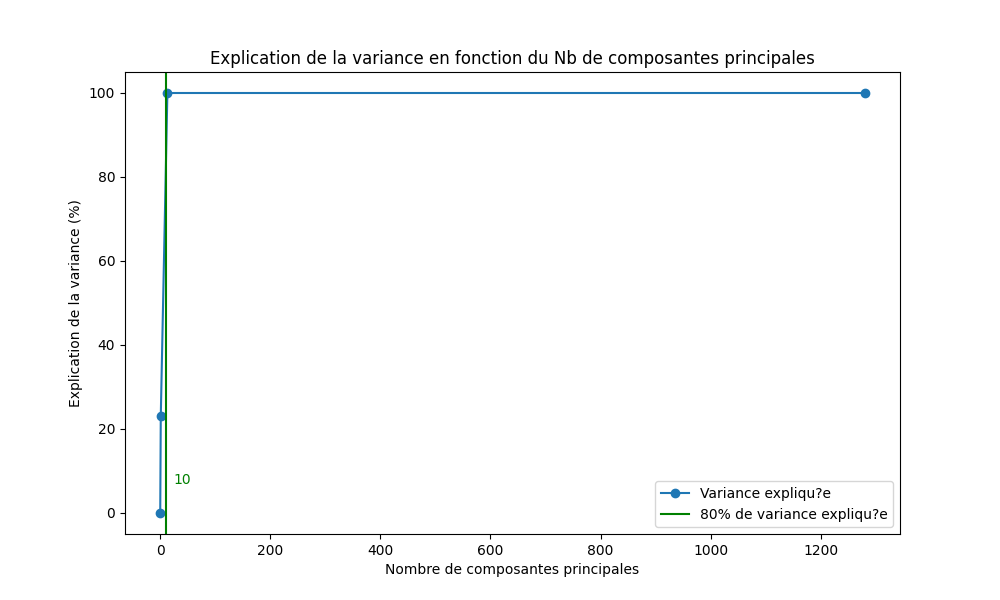

In [31]:
%matplot plt

In [32]:
Nb_composants_80 = math.ceil(x_80)
Nb_composants_80

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

10

In [33]:
from pyspark.ml.feature import PCA
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import VectorAssembler

spark.sparkContext.setLogLevel("ERROR")

# Conversion du DataFrame Pandas en DataFrame PySpark
df['features'] = df['features'].apply(lambda x: Vectors.dense(x))
df_spark = spark.createDataFrame(df)

# Création d'un VectorAssembler qui combine une liste de colonnes en une seule colonne de vecteur.
vecAssembler = VectorAssembler(inputCols=["features"], outputCol="features_vec")

# Utilisation du VectorAssembler pour transformer notre DataFrame.
df_spark = vecAssembler.transform(df_spark)

# Création d'un objet PCA 
pca = PCA(k=Nb_composants_80, inputCol="features_vec", outputCol="pcaFeatures")

# Entraînement du modèle PCA sur les données
model = pca.fit(df_spark)

# Transformation des données avec le modèle PCA
result = model.transform(df_spark)

# Suppression de la colonne 'features_vec'
result = result.drop('features_vec')

# Affichage des résultats
result.show()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+--------------------+--------------------+--------------------+--------------------+
|                path|               label|            features|         pcaFeatures|
+--------------------+--------------------+--------------------+--------------------+
|s3://projet-fruit...|           Apricot 1|[0.89959108829498...|[-4.6985515978086...|
|s3://projet-fruit...|Apple Granny Smith 1|[0.40983527898788...|[-5.2426590672939...|
|s3://projet-fruit...|           Avocado 1|[0.64239507913589...|[-10.317184451208...|
|s3://projet-fruit...|         Apple hit 1|[0.50753545761108...|[-2.1865114664019...|
|s3://projet-fruit...|           Apricot 1|[0.77396452426910...|[-1.7046531363843...|
|s3://projet-fruit...|           Avocado 1|[0.33077153563499...|[-7.5883349301282...|
|s3://projet-fruit...|            Banana 1|[0.04958038032054...|[19.2097741660803...|
|s3://projet-fruit...|         Apple Red 1|[0.12584045529365...|[-4.2315935571282...|
|s3://projet-fruit...|            Banana 1|[0.02801287

In [34]:
PATH = 's3://projet-fruits-nassima'
PATH_Data = PATH+'/Test'
PATH_Result_PCA = PATH+'/Results_PCA'
print('PATH:        '+\
      PATH+'\nPATH_Data:   '+\
      PATH_Data+'\nPATH_Results_PCA: '+PATH_Result_PCA)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

PATH:        s3://projet-fruits-nassima
PATH_Data:   s3://projet-fruits-nassima/Test
PATH_Results_PCA: s3://projet-fruits-nassima/Results_PCA

In [35]:
from pyspark.sql.functions import udf
from pyspark.ml.linalg import VectorUDT, DenseVector
from pyspark.sql.types import ArrayType, FloatType

# UDF pour convertir Vector en list
vector_to_list = udf(lambda v: v.toArray().tolist(), ArrayType(FloatType()))

# Appliquer la conversion
result = result.withColumn("features", vector_to_list(result["features"]))
result = result.withColumn("pcaFeatures", vector_to_list(result["pcaFeatures"]))

# Écrire dans Parquet
result.write.mode('overwrite').parquet(PATH_Result_PCA)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [36]:
df = pd.read_parquet(PATH_Result_PCA, engine='pyarrow')

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [37]:
df

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

                                                 path  ...                                        pcaFeatures
0   s3://projet-fruits-nassima/images/Test1/Aprico...  ...  [-4.6985517, 2.7504256, -5.620699, 3.635854, 5...
1   s3://projet-fruits-nassima/images/Test1/Apple ...  ...  [-5.242659, -1.6759598, 6.814036, 9.469623, 2....
2   s3://projet-fruits-nassima/images/Test1/Avocad...  ...  [-10.317184, 0.3593694, 13.6103735, -4.312967,...
3   s3://projet-fruits-nassima/images/Test1/Apple ...  ...  [-2.1865115, -25.89586, 2.1339402, -1.4702479,...
4   s3://projet-fruits-nassima/images/Test1/Aprico...  ...  [-1.7046531, -2.076825, -8.543089, 4.4382477, ...
5   s3://projet-fruits-nassima/images/Test1/Avocad...  ...  [-7.588335, -0.09110101, 8.558309, -4.6721897,...
6   s3://projet-fruits-nassima/images/Test1/Banana...  ...  [19.209774, -0.5817748, 5.934231, 2.0254169, 9...
7   s3://projet-fruits-nassima/images/Test1/Apple ...  ...  [-4.2315936, -3.8167071, -5.616968, -2.5096695...
8   s3://p

In [38]:
import s3fs

fs = s3fs.S3FileSystem()

with fs.open('s3://projet-fruits-nassima/Results_PCA/df_result_pca.csv', 'w') as f:
    df.to_csv(f, index=False)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…